# How concepts spread: early reach vs keeping fields

This notebook demos the **RQ2 trajectories** experiment. The question is how research concepts (for example
*Crowdsourcing* or *Graphics processing unit*) spread from their home field into other fields. It asks whether concepts that end up
**integrating** many fields do so mostly because they **reach many fields early** or because they **keep the
fields they enter**.

For each concept the number of off-home fields it retains at `t0+8` (`Bn`) is split exactly into three factors:

$$\log B_n = \underbrace{\log E_2}_{\text{early contact (fields entered by } t_0+2)} + \underbrace{\log M}_{\text{frontier advance } = E_H/E_2} + \underbrace{\log \rho}_{\text{retention } = B_n/E_H}$$

The gap in mean breadth between the **top** and **bottom** terciles of the integration outcome `O2r_resid` is then
split into shares `s_E2`, `s_M` and `s_rho`, stratified by early volume.

The pre-registered tests are:
* **PR1** (exploration > retention): `s_explore - s_ret > 0`.
* **PR2** (localised concepts keep more early): the early retention ratio is higher in the bottom tercile, and its partial Spearman correlation with `O2r_resid` given B5 is negative.

The original artifact ran on all 12,499 concepts (DEV 4,771; held-out 3,372; 2010–14 cohort 4,356) with 2,000
concept-bootstrap resamples. Its full-run results are **PR1 SUPPORTED** (DEV `s_explore - s_ret` = 0.633 [0.537, 0.727])
and **PR2 fails on the raw difference** (DEV reversed −0.110; only the partial-correlation clause holds).

**What this demo runs.** The original `method.py` is a *driver* that launches stage scripts (`s0`–`s10`) as
subprocesses over a 36 MB cache built from hundreds of millions of raw records, which is not available here. The
notebook therefore:
1. shows the driver code (`method.py`) and its stage plan unchanged;
2. copies the **S4 decomposition stage** (`lib/decomp.py`, the needed parts of `lib/rq1stats.py`, `s4_decomp.py`) unchanged;
3. runs that stage on a **100-concept DEV subset** (25 each from CS, Eng, BGM and Med) whose per-concept
   inputs (`E2`, `EH`, `Bn`, `O2r_resid`, B5 covariates, early retention ratio) come from the artifact's output file;
4. compares the demo numbers with the full-run headline numbers.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages used here are pre-installed on Colab -> install locally only (at Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

In [2]:
from __future__ import annotations

# --- original imports of method.py (the driver) ---
import argparse
import subprocess
import sys
import time
from pathlib import Path

# --- original imports of lib/decomp.py, lib/rq1stats.py and s4_decomp.py ---
import math
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import rankdata

# --- notebook additions ---
import json
import types
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_MjdbXJqg-rPl/round-4/experiment-12/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["method_name"])
print(data["metadata"]["demo_subset"])
print("examples:", len(data["datasets"][0]["examples"]))

RQ2 contact-vs-retention decomposition + trajectory typology/continuum (cache-only re-run)
100 DEV concepts (25 each from CS, Eng, BGM, Med) with a finite O2r_resid outcome, sampled with seed 20260929 from the 4,771-concept DEV frame of full_method_out.json
examples: 100


## Configuration

All tunable parameters are set here. The demo values are small so the notebook finishes in a few minutes. The
original values are in the comments.

In [5]:
# ---- tunable parameters (demo values; originals in comments) ----
N_BOOT = 2000          # concept-bootstrap resamples per variant   (original: N_BOOT = 2000, lib/common.py)
N_PLACEBO = 200       # T9 placebo shuffles                        (original: n = 200 in placebo())
WORKERS = 2          # process pool size for the variants        (original: --workers 24 / analyze(workers=13))
N_CONCEPTS = 100     # DEV concepts in mini_demo_data.json        (original: all 4,771 DEV concepts, 3,188 with an outcome)

# ---- fixed constants copied from lib/common.py ----
SEED = 20260929
B5 = ["logvol", "growth_c", "offhome_share", "entropy", "reach"]   # baseline covariates (early volume, growth, ...)

# Decomposition variants that can be computed from the per-concept fields in the demo data. The robustness
# variants that need extra count columns (_mn3/_mn5/_onset suffixes, O2r_m50, O1b) are only in the full cache.
DEMO_VARIANT_NAMES = ["i_pooled", "ii_vol_PRIMARY", "iii_vol_med_adjusted", "iv_vol_noMed_PR1", "ix_noEXP6_noMed"]

## 1. The pipeline driver (`method.py`)

This is the artifact's `method.py` as written. It runs the stages in order:
* **S0**: skeleton / frame.
* **S2**: early ego-network openness (OPEN).
* **S3**: D3 field-state sequences.
* **S4**: contact-vs-retention decomposition.
* **S5**: trajectory typology or continuum.
* **S6**: sequence test.
* **S7**: seal, then the held-out run.
* **S8**: case pairs.
* **S9**: AI atlas.
* **S10**: outputs.
* Checks: re-derivation (T7), unit tests (T0) and the headline audit.

Each stage is a separate script that reads a large local cache, so here we only print the plan and do not launch
it. The one change is that `ROOT` uses the working directory, because a notebook has no `__file__`. The next
sections run the **S4** stage in the notebook itself.

In [6]:
ROOT = Path.cwd()  # notebook: no __file__ (original: Path(__file__).resolve().parent)
PY = sys.executable


def steps(workers: int) -> list[tuple[str, list[str]]]:
    return [("S0", ["s0_skeleton.py"]),
            ("S2", ["s2_open.py", "--stage", "all", "--workers", str(workers)]),
            ("S3", ["s3_states.py"]),
            ("S4", ["s4_decomp.py", "--scope", "dev"]),
            ("S5", ["s5_typology.py", "--scope", "dev", "--workers", str(workers)]),
            ("S6", ["s6_sequence.py", "--scope", "dev"]),
            ("S7", ["s7_seal.py", "--freeze"] if not (ROOT / "logs/unsealed.json").exists() else []),
            ("S7run", ["s7_seal.py", "--run"]),
            ("S8", ["s8_cases.py"]),
            ("S9", ["s9_atlas.py"]),
            ("S10", ["s10_outputs.py"]),
            ("T7", ["rederive.py"]),
            ("T0", ["tests/test_units.py"]),
            ("AUDIT", ["audit_headlines.py"])]


def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--from", dest="start", default="S0")
    ap.add_argument("--workers", type=int, default=24)
    a = ap.parse_args()
    plan = steps(a.workers)
    names = [n for n, _ in plan]
    for name, cmd in plan[names.index(a.start):]:
        if not cmd:
            print(f"[{name}] skipped (already unsealed)")
            continue
        t = time.time()
        r = subprocess.run([PY, str(ROOT / cmd[0])] + cmd[1:], cwd=ROOT)
        print(f"[{name}] exit {r.returncode} in {time.time() - t:.0f}s")
        if r.returncode != 0:
            sys.exit(r.returncode)


# Notebook: dry-run of the plan (main() would subprocess.run each stage script; parse_args() is not usable in Jupyter)
for name, cmd in steps(WORKERS):
    print(f"[{name:5s}] python {' '.join(cmd) if cmd else '(skipped: already unsealed)'}")

[S0   ] python s0_skeleton.py
[S2   ] python s2_open.py --stage all --workers 2
[S3   ] python s3_states.py
[S4   ] python s4_decomp.py --scope dev
[S5   ] python s5_typology.py --scope dev --workers 2
[S6   ] python s6_sequence.py --scope dev
[S7   ] python s7_seal.py --freeze
[S7run] python s7_seal.py --run
[S8   ] python s8_cases.py
[S9   ] python s9_atlas.py
[S10  ] python s10_outputs.py
[T7   ] python rederive.py
[T0   ] python tests/test_units.py
[AUDIT] python audit_headlines.py


## 2. Decomposition library (`lib/decomp.py`), part 1: terciles, strata and the gap

Copied unchanged. `terciles` marks the top and bottom thirds of `O2r_resid`. `quantile_bins` builds the five
early-volume strata. `gap` computes, in each stratum, the group-level factors

* `Ebar` = mean `E2`
* `M_g` = ΣEH / ΣE2
* `rho_g` = ΣBn / ΣEH

so that mean `Bn` = `Ebar · M_g · rho_g` holds exactly. It then takes `D_k = log f_k(top) − log f_k(bottom)` and
averages over strata weighted by the number of concepts. Strata where a factor is undefined are merged with the
next stratum.

In [7]:
FACTORS = ["E2", "M", "rho"]
MIN_PER_TERCILE_CI = 30          # fallback 8: fewer concepts per tercile -> no CI, excluded from DL


def terciles(y: np.ndarray, by: np.ndarray | None) -> tuple[np.ndarray, np.ndarray]:
    """top / bottom tercile masks of y, computed within each level of `by` (or the whole sample)."""
    top = np.zeros(len(y), bool)
    bot = np.zeros(len(y), bool)
    levels = [None] if by is None else np.unique(by)
    for g in levels:
        m = np.ones(len(y), bool) if g is None else by == g
        if m.sum() < 3:
            continue
        lo, hi = np.quantile(y[m], [1 / 3, 2 / 3])
        top |= m & (y > hi)
        bot |= m & (y <= lo)
    return top, bot


def quantile_bins(v: np.ndarray, q: int) -> np.ndarray:
    edges = np.quantile(v, np.linspace(0, 1, q + 1)[1:-1])
    return np.searchsorted(edges, v, side="right")


def _factors(E2, EH, Bn) -> tuple[float, float, float]:
    se2, seh, sbn = E2.sum(), EH.sum(), Bn.sum()
    if len(E2) == 0 or se2 <= 0 or seh <= 0 or sbn <= 0:
        return (math.nan,) * 3
    return float(E2.mean()), float(seh / se2), float(sbn / seh)


def _stratum_ok(E2, EH, Bn, t, b) -> bool:
    return t.sum() > 0 and b.sum() > 0 and all(np.isfinite(_factors(E2[m], EH[m], Bn[m])).all() for m in (t, b))


def merge_strata(strata: np.ndarray, E2, EH, Bn, top, bot, family: np.ndarray | None = None) -> tuple[np.ndarray, int]:
    """merge adjacent (ordered) strata until each has valid factors in both terciles; within `family` levels."""
    out = strata.copy()
    merges = 0
    fams = [None] if family is None else np.unique(family)
    for f in fams:
        fm = np.ones(len(strata), bool) if f is None else family == f
        levels = sorted(np.unique(strata[fm]))
        buckets, cur = [], []
        for s in levels:
            cur.append(s)
            m = fm & np.isin(strata, cur)
            if _stratum_ok(E2, EH, Bn, top & m, bot & m):
                buckets.append(cur)
                cur = []
        if cur:
            if buckets:
                buckets[-1] = buckets[-1] + cur
            else:
                buckets.append(cur)
        merges += len(levels) - len(buckets)
        for bk in buckets:
            out[fm & np.isin(strata, bk)] = bk[0]
    return out, merges


def gap(E2, EH, Bn, top, bot, strata: np.ndarray | None = None, family: np.ndarray | None = None) -> dict:
    """D_k (n-weighted over strata), shares, and the unstratified factor levels."""
    if strata is None:
        strata = np.zeros(len(E2), int)
    st, merges = merge_strata(strata, E2, EH, Bn, top, bot, family)
    keys = st * 1000 + (0 if family is None else family)
    Dw = np.zeros(3)
    W = 0.0
    n_str = 0
    for s in np.unique(keys):
        m = keys == s
        t, b = top & m, bot & m
        ft, fb = _factors(E2[t], EH[t], Bn[t]), _factors(E2[b], EH[b], Bn[b])
        if not (np.isfinite(ft).all() and np.isfinite(fb).all()):
            continue
        w = float(t.sum() + b.sum())
        Dw += w * (np.log(ft) - np.log(fb))
        W += w
        n_str += 1
    D = Dw / W if W > 0 else np.full(3, np.nan)
    tot = D.sum()
    sh = D / tot if np.isfinite(tot) and abs(tot) > 1e-12 else np.full(3, np.nan)
    ft, fb = _factors(E2[top], EH[top], Bn[top]), _factors(E2[bot], EH[bot], Bn[bot])
    return {"D_E2": D[0], "D_M": D[1], "D_rho": D[2], "D_total": tot, "s_E2": sh[0], "s_M": sh[1], "s_rho": sh[2],
            "s_explore": sh[0] + sh[1], "s_contact": sh[0], "s_ret": sh[2],
            "diff_explore_ret": (sh[0] + sh[1]) - sh[2], "diff_contact_ret": sh[0] - sh[2],
            "top_Ebar": ft[0], "top_M": ft[1], "top_rho": ft[2], "bot_Ebar": fb[0], "bot_M": fb[1], "bot_rho": fb[2],
            "top_Bbar": float(Bn[top].mean()) if top.any() else math.nan,
            "bot_Bbar": float(Bn[bot].mean()) if bot.any() else math.nan,
            "n_top": int(top.sum()), "n_bot": int(bot.sum()), "n_strata": n_str, "merges": merges}

## 3. Decomposition library, part 2: Das Gupta, the covariance check, bootstrap and verdicts

Copied unchanged. These functions do the following:
* `das_gupta` is an additive (rather than log) three-factor decomposition, used as a robustness check.
* `concept_cov` splits `var(log Bn)` into covariances with each log factor. It also reports the error of the exact identity, which should be about 0.
* `run_variant` computes the point estimate and then a concept bootstrap that recomputes the terciles and volume strata in every resample.
* `verdict` maps a CI to SUPPORTED / NOT SUPPORTED / REVERSED.

The stage code calls these through the module name `DC`. We rebuild that namespace from the functions defined
above.

In [8]:
def das_gupta(E2, EH, Bn, top, bot) -> dict:
    """additive 3-factor Das Gupta decomposition of Bbar(top) - Bbar(bottom) (pooled)."""
    a1, b1, c1 = _factors(E2[top], EH[top], Bn[top])
    a2, b2, c2 = _factors(E2[bot], EH[bot], Bn[bot])

    def eff(x1, x2, y1, y2, z1, z2):
        return (x1 - x2) * ((y1 * z1 + y2 * z2) / 3 + (y1 * z2 + y2 * z1) / 6)
    eA = eff(a1, a2, b1, b2, c1, c2)
    eB = eff(b1, b2, a1, a2, c1, c2)
    eC = eff(c1, c2, a1, a2, b1, b2)
    g = a1 * b1 * c1 - a2 * b2 * c2
    return {"effect_E2": eA, "effect_M": eB, "effect_rho": eC, "gap_Bbar": g, "sum_effects": eA + eB + eC,
            "share_E2": eA / g, "share_M": eB / g, "share_rho": eC / g}


def concept_cov(E2, EH, Bn) -> dict:
    """exact covariance decomposition var(log Bn) = sum_k cov(log Bn, log f_k) among Bn >= 1."""
    m = (Bn >= 1) & (E2 >= 1)
    lb = np.log(Bn[m])
    le, lm, lr = np.log(E2[m]), np.log(EH[m] / E2[m]), np.log(Bn[m] / EH[m])
    v = lb.var()
    cs = [float(np.cov(lb, x, bias=True)[0, 1]) for x in (le, lm, lr)]
    return {"n": int(m.sum()), "var_logBn": float(v), "cov_E2": cs[0], "cov_M": cs[1], "cov_rho": cs[2],
            "share_E2": cs[0] / v, "share_M": cs[1] / v, "share_rho": cs[2] / v,
            "identity_max_abs_err": float(np.max(np.abs(lb - (le + lm + lr)))) if m.any() else 0.0}


def run_variant(d: dict, spec: dict, rng: np.random.Generator | None, n_boot: int) -> dict:
    """d: arrays E2, EH, Bn, y (tercile outcome), logvol_early, med, tby (tercile-within levels or None),
    rs (resampling strata, e.g. unit). spec: strata in {none, vol, vol_med}."""
    def once(idx: np.ndarray | None) -> dict:
        g = (lambda a: a) if idx is None else (lambda a: None if a is None else a[idx])  # noqa: E731
        E2, EH, Bn, y = g(d["E2"]), g(d["EH"]), g(d["Bn"]), g(d["y"])
        top, bot = terciles(y, g(d.get("tby")))
        strata = family = None
        if spec["strata"] in ("vol", "vol_med"):
            lv = g(d["logvol_early"])
            tb = g(d.get("tby"))
            if tb is None:
                strata = quantile_bins(lv, 5)
            else:  # quintiles within each tercile-level (unit) so strata never mix units
                strata = np.zeros(len(lv), int)
                for u in np.unique(tb):
                    m = tb == u
                    strata[m] = quantile_bins(lv[m], 5)
                family = np.unique(tb, return_inverse=True)[1]
        if spec["strata"] == "vol_med":
            med = g(d["med"]).astype(int)
            family = med if family is None else family * 2 + med
        return gap(E2, EH, Bn, top, bot, strata, family)
    point = once(None)
    out = {"point": point, "n": int(len(d["E2"]))}
    if rng is None or n_boot <= 0:
        return out
    n = len(d["E2"])
    rs = d.get("rs")
    groups = [np.arange(n)] if rs is None else [np.nonzero(rs == u)[0] for u in np.unique(rs)]
    keys = ["D_E2", "D_M", "D_rho", "D_total", "s_E2", "s_M", "s_rho", "s_explore", "s_contact", "s_ret",
            "diff_explore_ret", "diff_contact_ret"]
    B = {k: np.empty(n_boot) for k in keys}
    for b in range(n_boot):
        idx = np.concatenate([gi[rng.integers(0, len(gi), len(gi))] for gi in groups])
        r = once(idx)
        for k in keys:
            B[k][b] = r[k]
    out["ci"] = {k: [float(np.nanpercentile(v, 2.5)), float(np.nanpercentile(v, 97.5))] for k, v in B.items()}
    out["se"] = {k: float(np.nanstd(v, ddof=1)) for k, v in B.items()}
    out["p_two_sided"] = {k: float(min(1.0, 2 * min(np.nanmean(v <= 0), np.nanmean(v >= 0)))) for k, v in B.items()}
    out["boot_nan_share"] = float(np.mean(~np.isfinite(B["s_ret"])))
    out["_boot"] = B
    return out


def verdict(ci: list[float]) -> str:
    lo, hi = ci
    if not (np.isfinite(lo) and np.isfinite(hi)):
        return "NOT EVALUABLE"
    if lo > 0:
        return "SUPPORTED"
    if hi < 0:
        return "REVERSED"
    return "NOT SUPPORTED"


# notebook: s4_decomp.py does `import decomp as DC`; expose the functions defined above under the same name
DC = types.SimpleNamespace(terciles=terciles, quantile_bins=quantile_bins, gap=gap, das_gupta=das_gupta,
                           concept_cov=concept_cov, run_variant=run_variant, verdict=verdict,
                           MIN_PER_TERCILE_CI=MIN_PER_TERCILE_CI, FACTORS=FACTORS)

## 4. Statistics helpers (`lib/rq1stats.py`)

These are the functions that S4 uses, copied unchanged:
* `psp_boot` is a partial Spearman correlation given the B5 baseline. It rank-transforms the data, residualises on the B5 ranks and bootstraps concepts, refitting in every resample. PR2 uses it.
* `dersimonian_laird` does random-effects pooling. The held-out run uses it.
* `holm` applies the Holm correction to the PR1 / PR1b / PR2 family.

In [9]:
def _resid(Z: np.ndarray, Y: np.ndarray) -> np.ndarray:
    beta, *_ = np.linalg.lstsq(Z, Y, rcond=None)
    return Y - Z @ beta


def psp_point(x: np.ndarray, y: np.ndarray, B: np.ndarray, cat: np.ndarray | None) -> float:
    """Pearson(resid(rank x ~ rank B + cat dummies), resid(rank y ~ same)). Rows must be complete."""
    Zc = [np.ones((len(x), 1))]
    if B is not None and B.shape[1]:
        Zc.append(rankdata(B, axis=0))
    if cat is not None and cat.shape[1]:
        Zc.append(cat)
    Z = np.hstack(Zc)
    R = _resid(Z, np.c_[rankdata(x), rankdata(y)])
    sx, sy = R[:, 0].std(), R[:, 1].std()
    if sx <= 1e-12 or sy <= 1e-12:
        return float("nan")
    return float(np.corrcoef(R[:, 0], R[:, 1])[0, 1])


def psp_boot(x, y, B, cat, n_boot: int, seed: int) -> dict:
    """Point + concept bootstrap (resample rows; ranks and residualisation recomputed in each resample)."""
    ok = np.isfinite(x) & np.isfinite(y)
    if B is not None:
        ok &= np.all(np.isfinite(B), axis=1)
    x, y = x[ok], y[ok]
    Bs = B[ok] if B is not None else None
    cs = cat[ok] if cat is not None else None
    n = len(x)
    if n < 20 or np.unique(x).size < 3:
        return {"n": int(n), "rho": float("nan"), "ci": [float("nan")] * 2, "se": float("nan"), "p": float("nan"),
                "boot": np.array([])}
    est = psp_point(x, y, Bs, cs)
    rng = np.random.default_rng(seed)
    bs = np.empty(n_boot)
    for b in range(n_boot):
        i = rng.integers(0, n, n)
        bs[b] = psp_point(x[i], y[i], Bs[i] if Bs is not None else None, cs[i] if cs is not None else None)
    bs = bs[np.isfinite(bs)]
    lo, hi = np.percentile(bs, [2.5, 97.5]) if len(bs) else (np.nan, np.nan)
    z = np.arctanh(np.clip(bs, -0.999999, 0.999999))
    se_z = float(np.std(z, ddof=1)) if len(z) > 2 else float("nan")
    ze = math.atanh(max(min(est, 0.999999), -0.999999)) if np.isfinite(est) else float("nan")
    p = float(2 * stats.norm.sf(abs(ze / se_z))) if se_z and np.isfinite(se_z) and se_z > 0 else float("nan")
    return {"n": int(n), "rho": est, "ci": [float(lo), float(hi)], "se": float(np.std(bs, ddof=1)),
            "z": ze, "se_z": se_z, "p": p, "boot": bs}


def dersimonian_laird(b, se) -> dict:
    """EXP6 lib/stats_core.dersimonian_laird (verbatim logic)."""
    b, se = np.asarray(b, float), np.asarray(se, float)
    ok = np.isfinite(b) & np.isfinite(se) & (se > 0)
    b, se = b[ok], se[ok]
    k = len(b)
    if k == 0:
        return {"k": 0, "b": float("nan"), "se": float("nan"), "ci": [float("nan")] * 2, "p": float("nan"),
                "tau2": float("nan"), "I2": float("nan"), "Q": float("nan")}
    w = 1 / se**2
    bf = (w * b).sum() / w.sum()
    Q = float((w * (b - bf) ** 2).sum())
    Cc = w.sum() - (w**2).sum() / w.sum()
    tau2 = max(0.0, (Q - (k - 1)) / Cc) if k > 1 and Cc > 0 else 0.0
    ws = 1 / (se**2 + tau2)
    bre = (ws * b).sum() / ws.sum()
    sre = math.sqrt(1 / ws.sum())
    I2 = max(0.0, (Q - (k - 1)) / Q) if Q > 0 and k > 1 else 0.0
    return {"k": k, "b": float(bre), "se": sre, "ci": [float(bre - 1.96 * sre), float(bre + 1.96 * sre)],
            "p": float(2 * stats.norm.sf(abs(bre / sre))), "tau2": float(tau2), "Q": Q, "I2": float(I2)}


def holm(p: list[float]) -> list[float]:
    p = np.asarray(p, float)
    out = np.full(len(p), np.nan)
    ok = np.isfinite(p)
    idx = np.nonzero(ok)[0]
    m = len(idx)
    order = idx[np.argsort(p[idx])]
    run = 0.0
    for r, i in enumerate(order):
        run = max(run, min(1.0, (m - r) * p[i]))
        out[i] = run
    return out.tolist()

## 5. Pre-registration and decomposition variants (`s4_decomp.py`)

The pre-registered predictions were hash-sealed on DEV before any held-out data was read. Each entry in
`VARIANTS` maps a name to `(strata, subset, outcome column, count suffix)`. **Variant (iv)** tests PR1:
volume-stratified, with Medicine-home concepts excluded. Variant (ii) is the primary descriptive decomposition.

In [10]:
PREREG = {
    "PR1": ("EXPLORATION > RETENTION: in variant (iv) [volume-stratified (early-volume quintiles), concepts with a "
            "Medicine (field 27) home excluded], s_explore - s_ret > 0 with the 95% concept-bootstrap CI > 0, where "
            "s_explore = s_E2 + s_M and s_ret = s_rho are the shares of the top-vs-bottom O2r_resid tercile gap in "
            "log mean breadth (Bn = retained off-home fields at t0+8). Equivalently s_ret < 0.5; both are printed "
            "(shares sum to 1)."),
    "PR1b": "(secondary, Holm family R2-A with PR1 and PR2): s_contact - s_ret > 0 with CI > 0 (s_contact = s_E2).",
    "PR2": ("LOCALISED KEEP MORE EARLY: mean RETENTION_RATIO_early(bottom O2r_resid tercile) - mean(top tercile) > 0 "
            "with CI > 0, AND the partial Spearman of RETENTION_RATIO_early with O2r_resid given B5 < 0 (CI < 0). The "
            "latter is flagged 'replication on the same frame as EXP8, not new evidence'."),
    "PR3": "(descriptive, not tested): the sign of D_rho, i.e. whether late retention probability is lower for "
           "integrating (top-tercile) concepts.",
    "verdict_rule": "per clause: SUPPORTED (CI on the predicted side) / NOT SUPPORTED (CI covers 0) / REVERSED "
                    "(CI on the opposite side); evaluated separately on DEV and on held-out.",
    "holm_family_R2A": ["PR1", "PR1b", "PR2"],
}

VARIANTS = {   # name: (strata, subset, y column, decomp suffix)
    "i_pooled": ("none", None, "O2r_resid", ""),
    "ii_vol_PRIMARY": ("vol", None, "O2r_resid", ""),
    "iii_vol_med_adjusted": ("vol_med", None, "O2r_resid", ""),
    "iv_vol_noMed_PR1": ("vol", "nomed", "O2r_resid", ""),
    "v_minn3": ("vol", None, "O2r_resid", "_mn3"),
    "v_minn5": ("vol", None, "O2r_resid", "_mn5"),
    "v_minn3_noMed": ("vol", "nomed", "O2r_resid", "_mn3"),
    "v_minn5_noMed": ("vol", "nomed", "O2r_resid", "_mn5"),
    "vi_O2r_m50": ("vol", None, "O2r_m50", ""),
    "vi_O1b_sustained_only": ("vol", "o1b", "O2r_resid", ""),
    "viii_onset_restricted": ("vol", None, "O2r_resid", "_onset"),
    "viii_onset_restricted_noMed": ("vol", "nomed", "O2r_resid", "_onset"),
    "ix_noEXP6_noMed": ("vol", "noexp6_nomed", "O2r_resid", ""),
}
BOOT_KEYS = ["D_E2", "D_M", "D_rho", "diff_explore_ret", "diff_contact_ret", "s_ret"]


# notebook: keep only the variants computable from the demo data (see config cell)
DEMO_VARIANTS = {k: VARIANTS[k] for k in DEMO_VARIANT_NAMES}
print(json.dumps(PREREG["PR1"], indent=1)[:400], "...")

"EXPLORATION > RETENTION: in variant (iv) [volume-stratified (early-volume quintiles), concepts with a Medicine (field 27) home excluded], s_explore - s_ret > 0 with the 95% concept-bootstrap CI > 0, where s_explore = s_E2 + s_M and s_ret = s_rho are the shares of the top-vs-bottom O2r_resid tercile gap in log mean breadth (Bn = retained off-home fields at t0+8). Equivalently s_ret < 0.5; both are ...


## 6. Build the concept table (replaces `load_table`)

The original `load_table(scope)` joins `data/joined.parquet`, `data/decomp_inputs.parquet` and the sealed EXP8
outcomes, then sets `logvol_early = log(early_volume)`. Here we build the same columns from the demo JSON. Each
example's `input` holds the B5 covariates and the early retention ratio. Its `output` holds `E2`, `EH`, `Bn` and
`O2r_resid`. `logvol` in B5 equals `log(early_volume)` in the original cache.

In [11]:
rows = []
for ex in data["datasets"][0]["examples"][:N_CONCEPTS]:
    inp, out = json.loads(ex["input"]), json.loads(ex["output"])
    rr = inp.get("RETENTION_RATIO_early")
    rows.append({"ci": ex["metadata_ci"], "name": inp["name"], "group": ex["metadata_group"],
                 "split": ex["metadata_split"], "unit": ex["metadata_unit"], "med_home": ex["metadata_med_home"],
                 "in_exp6": ex["metadata_in_exp6"], **inp["B5"],
                 "early_volume": float(np.exp(inp["B5"]["logvol"])),
                 "RETENTION_RATIO_early": np.nan if rr is None else rr,
                 "RETENTION_RATIO_missing": int(rr is None or not np.isfinite(rr)),
                 "OPEN_all": inp["OPEN_all"], "O2r_resid": out["O2r_resid"],
                 "E2": out["E2"], "EH": out["EH"], "Bn": out["Bn"], "PC1": out["PC1"], "PC2": out["PC2"],
                 "tercile_full": out["O2r_resid_tercile"]})
T = pd.DataFrame(rows)
T["logvol_early"] = np.log(T.early_volume)      # original line from load_table()
print(T.shape)
print(T.groupby("group")[["E2", "EH", "Bn", "O2r_resid"]].mean().round(2))
T.head()

(100, 24)
         E2    EH    Bn  O2r_resid
group                             
BGM    4.16  6.44  4.00       1.23
CS     3.40  6.12  4.20       0.69
Eng    3.28  5.12  2.44      -0.11
Med    2.60  4.28  2.32      -0.55


,ci,name,group,split,unit,med_home,in_exp6,logvol,growth_c,offhome_share,...,RETENTION_RATIO_missing,OPEN_all,O2r_resid,E2,EH,Bn,PC1,PC2,tercile_full,logvol_early
0,7851,Crowdsourcing,CS,DEV,CS,0,1,5.513429,1.691676,0.610000,...,0,3.640158,5.308775,7,17,15,13.781626,3.713609,top,5.513429
1,409,Service innovation,CS,DEV,CS,0,0,4.584967,0.565314,0.619718,...,0,0.367473,1.629330,3,6,4,7.128854,4.135356,top,4.584967
2,29881,COBIT,CS,DEV,CS,0,0,4.276666,0.298493,0.538462,...,0,0.380269,-0.034969,3,4,3,4.939560,2.784071,middle,4.276666
3,23636,Application layer,CS,DEV,CS,0,0,4.442651,0.066691,0.000000,...,0,-0.369164,-1.503883,1,1,1,-3.619867,3.443231,bottom,4.442651
4,8888,Dimensionality reduction,CS,DEV,CS,0,0,4.605170,0.062520,0.515625,...,0,0.677090,3.582956,7,12,9,11.513118,2.026014,top,4.605170


## 7. Per-variant job, array builder and subsets (`s4_decomp.py`)

Copied unchanged. `_job` runs one variant: it filters the subset, runs `DC.run_variant` with the bootstrap, and
records the bootstrap quantiles. `ci_reported` is True only when each tercile has at least 30 concepts. On the
100-concept demo each tercile has about 33 concepts, so this is borderline.

In [12]:
def arrays(T: pd.DataFrame, suffix: str, ycol: str, tby=None, rs=None) -> dict:
    return {"E2": T[f"E2{suffix}"].to_numpy(float), "EH": T[f"EH{suffix}"].to_numpy(float),
            "Bn": T[f"Bn{suffix}"].to_numpy(float), "y": T[ycol].to_numpy(float),
            "logvol_early": T.logvol_early.to_numpy(float), "med": T.med_home.to_numpy(int),
            "tby": None if tby is None else T[tby].to_numpy(), "rs": None if rs is None else T[rs].to_numpy()}


def subset(T: pd.DataFrame, which: str | None) -> pd.DataFrame:
    if which is None:
        return T
    if which == "nomed":
        return T[T.med_home == 0]
    if which == "o1b":   # plan says 'O1c = 1'; O1c is continuous in EXP8, the binary sustained-uptake outcome is O1b
        return T[T.O1b == 1]
    if which == "noexp6_nomed":
        return T[(T.med_home == 0) & (T.in_exp6 == 0)]
    raise ValueError(which)


def _job(args):
    name, T, spec, tby, rs, seed, n_boot = args
    strata, sub, ycol, suf = spec
    S = subset(T, sub)
    S = S[np.isfinite(S[ycol])]
    res = DC.run_variant(arrays(S, suf, ycol, tby, rs), {"strata": strata}, np.random.default_rng(seed), n_boot)
    B = res.pop("_boot", None)
    res["boot_quantiles"] = {k: np.nanpercentile(B[k], [2.5, 5, 25, 50, 75, 95, 97.5]).tolist()
                             for k in BOOT_KEYS} if B is not None else None
    res["spec"] = {"strata": strata, "subset": sub, "y": ycol, "counts_suffix": suf or "min_n=2"}
    tn = min(res["point"]["n_top"], res["point"]["n_bot"])
    res["ci_reported"] = tn >= DC.MIN_PER_TERCILE_CI
    return name, res

## 8. PR2: early retention ratio (`early_ratio`)

Copied unchanged. It computes the mean `RETENTION_RATIO_early` in the bottom tercile minus the top tercile, with
a bootstrap CI. It also computes the partial Spearman correlation of the ratio with `O2r_resid` given B5. PR2 is
SUPPORTED only if *both* clauses hold.

In [13]:
def early_ratio(T: pd.DataFrame, seed: int, n_boot: int, tby=None) -> dict:
    """PR2: RETENTION_RATIO_early bottom - top tercile (concepts with >= 1 off-home contact) + psp given B5."""
    S = T[np.isfinite(T.O2r_resid) & (T.RETENTION_RATIO_missing == 0)]
    y = S.O2r_resid.to_numpy()
    rr = S.RETENTION_RATIO_early.to_numpy()
    tb = None if tby is None else S[tby].to_numpy()
    rng = np.random.default_rng(seed)

    def diff(idx):
        top, bot = DC.terciles(y[idx], None if tb is None else tb[idx])
        return rr[idx][bot].mean() - rr[idx][top].mean()
    n = len(S)
    pt = diff(np.arange(n))
    bs = np.array([diff(rng.integers(0, n, n)) for _ in range(n_boot)])
    ps = psp_boot(rr, y, S[B5].to_numpy(float), None, n_boot, seed + 7)
    top, bot = DC.terciles(y, tb)
    return {"n": n, "mean_bottom": float(rr[bot].mean()), "mean_top": float(rr[top].mean()),
            "diff_bottom_minus_top": float(pt), "ci": np.percentile(bs, [2.5, 97.5]).tolist(),
            "se": float(bs.std(ddof=1)), "p_two_sided": float(min(1, 2 * min((bs <= 0).mean(), (bs >= 0).mean()))),
            "psp_given_B5": {k: ps[k] for k in ("n", "rho", "ci", "se", "p")},
            "note_psp": "replication on the same frame as EXP8, not new evidence"}

## 9. Analysis, verdicts and placebo (`analyze`, `verdicts`, `placebo`)

Copied unchanged:
* `analyze` runs every variant in a process pool, then adds the pooled Das Gupta and covariance checks and the two PR2 blocks.
* `verdicts` applies the pre-registered rules together with the Holm correction.
* `placebo` (T9) shuffles `O2r_resid` within group. On the full DEV frame the `D_k` are close to 0 under that null. On the 100-concept demo the placebo gap is noisy and can be clearly non-zero.

In [14]:
def analyze(T: pd.DataFrame, label: str, seed: int, tby=None, rs=None, n_boot: int = N_BOOT,
            variants=VARIANTS, workers: int = 13) -> dict:
    jobs = [(name, T, spec, tby, rs, seed + k, n_boot) for k, (name, spec) in enumerate(variants.items())]
    with ProcessPoolExecutor(min(workers, len(jobs))) as ex:
        res = dict(ex.map(_job, jobs))
    out = {"label": label, "n_concepts_with_outcome": int(np.isfinite(T.O2r_resid).sum()), "variants": res}
    S = T[np.isfinite(T.O2r_resid)]
    top, bot = DC.terciles(S.O2r_resid.to_numpy(), None if tby is None else S[tby].to_numpy())
    a = arrays(S, "", "O2r_resid")
    out["das_gupta_pooled"] = DC.das_gupta(a["E2"], a["EH"], a["Bn"], top, bot)
    out["concept_level_cov"] = DC.concept_cov(a["E2"], a["EH"], a["Bn"])
    out["early_ratio_PR2"] = early_ratio(T, seed + 99, n_boot, tby)
    out["early_ratio_PR2_noMed"] = early_ratio(T[T.med_home == 0], seed + 98, n_boot, tby)
    return out


def verdicts(res: dict) -> dict:
    v = res["variants"]["iv_vol_noMed_PR1"]
    er = res["early_ratio_PR2"]
    p1 = v["p_two_sided"]["diff_explore_ret"]
    p1b = v["p_two_sided"]["diff_contact_ret"]
    p2 = max(er["p_two_sided"], er["psp_given_B5"]["p"])
    ph = holm([p1, p1b, p2])
    pr2a = DC.verdict(er["ci"])
    pr2b = DC.verdict([-er["psp_given_B5"]["ci"][1], -er["psp_given_B5"]["ci"][0]])
    pr2 = "SUPPORTED" if (pr2a == pr2b == "SUPPORTED") else ("REVERSED" if "REVERSED" in (pr2a, pr2b)
                                                              else "NOT SUPPORTED")
    return {"PR1": {"verdict": DC.verdict(v["ci"]["diff_explore_ret"]), "s_explore_minus_s_ret": v["point"]["diff_explore_ret"],
                    "ci": v["ci"]["diff_explore_ret"], "s_ret": v["point"]["s_ret"], "s_ret_ci": v["ci"]["s_ret"],
                    "s_ret_below_0.5": bool(v["ci"]["s_ret"][1] < 0.5), "p": p1, "p_holm": ph[0]},
            "PR1b": {"verdict": DC.verdict(v["ci"]["diff_contact_ret"]), "s_contact_minus_s_ret": v["point"]["diff_contact_ret"],
                     "ci": v["ci"]["diff_contact_ret"], "p": p1b, "p_holm": ph[1]},
            "PR2": {"verdict": pr2, "clause_diff": pr2a, "clause_psp_negative": pr2b, "p_iut": p2, "p_holm": ph[2],
                    "diff": er["diff_bottom_minus_top"], "diff_ci": er["ci"], "psp": er["psp_given_B5"]["rho"],
                    "psp_ci": er["psp_given_B5"]["ci"]},
            "PR3_descriptive": {"D_rho": v["point"]["D_rho"], "ci": v["ci"]["D_rho"],
                                "sign": "negative (integrating concepts keep a SMALLER share of entered fields)"
                                if v["point"]["D_rho"] < 0 else "positive (integrating concepts keep a LARGER share)"}}


def placebo(T: pd.DataFrame, seed: int, n: int = 200, by: str = "group") -> dict:
    """T9: shuffle O2r_resid within group; primary (ii) and PR1 (iv) point estimates under the null."""
    rng = np.random.default_rng(seed)
    S = T[np.isfinite(T.O2r_resid)].copy()
    out = {}
    for name in ("ii_vol_PRIMARY", "iv_vol_noMed_PR1"):
        strata, sub, ycol, suf = VARIANTS[name]
        X = subset(S, sub).copy()
        vals = {k: [] for k in ("diff_explore_ret", "D_E2", "D_M", "D_rho", "D_total")}
        for _ in range(n):
            X["y_shuf"] = X.groupby(by).O2r_resid.transform(lambda s: rng.permutation(s.to_numpy()))
            r = DC.run_variant(arrays(X, suf, "y_shuf"), {"strata": strata}, None, 0)["point"]
            for k in vals:
                vals[k].append(r[k])
        out[name] = {k: {"mean": float(np.nanmean(v)), "q025_q975": np.nanpercentile(v, [2.5, 97.5]).tolist(),
                         "nan_share": float(np.mean(~np.isfinite(v)))} for k, v in vals.items()}
    out["note"] = ("under the null the total gap D_total is ~0, so shares are unstable by construction; the D_k "
                   "log-ratios are the stable quantities")
    return out

## 10. Run the DEV analysis (the `--scope dev` branch of `s4_decomp.main`)

These are the same calls as the original DEV branch, with these changes:
* `N_BOOT`, `WORKERS` and `N_PLACEBO` come from the config cell.
* Only the demo-computable variants are run.
* Nothing is written to `results/`.

The per-group analyses (`dev_groups`) use only about 25 concepts each in the demo, so they can be `NaN` or very noisy.

In [15]:
t_start = time.time()
res = analyze(T, "DEV", SEED + 400, n_boot=N_BOOT, variants=DEMO_VARIANTS, workers=WORKERS)
res["verdicts"] = verdicts(res)
res["dev_groups"] = {g: analyze(T[T.group == g], f"DEV_{g}", SEED + 410 + k, n_boot=N_BOOT,
                                variants={kk: VARIANTS[kk] for kk in ("ii_vol_PRIMARY", "i_pooled")}, workers=WORKERS)
                     for k, g in enumerate(["CS", "Eng", "BGM", "Med"])}
# T5: second bootstrap seed for the PR1 variant
_, r2 = _job(("iv_seed2", T, VARIANTS["iv_vol_noMed_PR1"], None, None, SEED + 777, N_BOOT))
v1 = res["variants"]["iv_vol_noMed_PR1"]["ci"]
res["T5_second_seed"] = {k: {"seed1": v1[k], "seed2": r2["ci"][k],
                             "max_end_shift": float(np.max(np.abs(np.subtract(v1[k], r2["ci"][k]))))}
                         for k in ("diff_explore_ret", "diff_contact_ret", "D_E2", "D_M", "D_rho")}
res["T9_placebo"] = placebo(T, SEED + 900, n=N_PLACEBO)
v = res["verdicts"]
print(f"DEV PR1 {v['PR1']['verdict']} diff {v['PR1']['s_explore_minus_s_ret']:.3f} {np.round(v['PR1']['ci'], 3).tolist()}; "
      f"PR1b {v['PR1b']['verdict']}; PR2 {v['PR2']['verdict']} ({v['PR2']['clause_diff']}, "
      f"{v['PR2']['clause_psp_negative']}); D_rho {v['PR3_descriptive']['D_rho']:.3f}")
print(f"runtime {time.time() - t_start:.1f}s")

/tmp/ipykernel_584/3498570354.py:11: RuntimeWarning: Mean of empty slice.
  return rr[idx][bot].mean() - rr[idx][top].mean()
/tmp/aii_nb_test_envs/art_uw4OeagJP3rv-3a092170af1d/lib/python3.12/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_584/3498570354.py:17: RuntimeWarning: Mean of empty slice.
  return {"n": n, "mean_bottom": float(rr[bot].mean()), "mean_top": float(rr[top].mean()),
/tmp/aii_nb_test_envs/art_uw4OeagJP3rv-3a092170af1d/lib/python3.12/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


DEV PR1 SUPPORTED diff 0.996 [0.554, 1.365]; PR1b SUPPORTED; PR2 REVERSED (REVERSED, NOT SUPPORTED); D_rho 0.002
runtime 16.4s


## 11. Results: demo subset vs full run

The tables compare the demo's decomposition shares and verdicts with the headline numbers from the full
4,771-concept DEV run with 2,000 bootstrap resamples (stored in the data file's metadata). With only 100 concepts
the CIs are wide and the verdicts can differ. The identity check (`concept_cov` max error) should still be about
1e-16. The figures show:
* the stratified `D_k` log-ratio contributions;
* the covariance-decomposition shares;
* a plot relating the OPEN score to the trajectory-continuum axis PC1.

In [16]:
H = data["metadata"]["headline"]
pv, pp = res["variants"]["iv_vol_noMed_PR1"]["point"], res["variants"]["ii_vol_PRIMARY"]["point"]
tab = pd.DataFrame({
    "demo (ii) primary": [pp["s_E2"], pp["s_M"], pp["s_rho"], pp["diff_explore_ret"]],
    "full (ii) primary": [H["shares_DEV_primary"]["s_E2"], H["shares_DEV_primary"]["s_M"], H["shares_DEV_primary"]["s_rho"], np.nan],
    "demo (iv) PR1": [pv["s_E2"], pv["s_M"], pv["s_rho"], pv["diff_explore_ret"]],
    "full (iv) PR1": [H["shares_DEV_PR1_variant"]["s_E2"], H["shares_DEV_PR1_variant"]["s_M"],
                      H["shares_DEV_PR1_variant"]["s_rho"], H["PR1_DEV"]["s_explore_minus_s_ret"]],
}, index=["s_E2 (early contact)", "s_M (frontier advance)", "s_rho (retention)", "s_explore - s_ret"])
print("Shares of the top-vs-bottom breadth gap")
print(tab.round(3).to_string())

vt = pd.DataFrame({"demo verdict": [v["PR1"]["verdict"], v["PR1b"]["verdict"], v["PR2"]["verdict"]],
                   "full DEV verdict": [H["PR_verdicts_DEV"][k] for k in ("PR1", "PR1b", "PR2")]},
                  index=["PR1", "PR1b", "PR2"])
print("\nPre-registered verdicts"); print(vt.to_string())
print("\nPR2 demo: diff bottom-top", round(v["PR2"]["diff"], 3), np.round(v["PR2"]["diff_ci"], 3).tolist(),
      "| psp given B5", round(v["PR2"]["psp"], 3), "   (full DEV:", round(H["PR2_DEV"]["diff"], 3), "/", round(H["PR2_DEV"]["psp"], 3), ")")
cc = res["concept_level_cov"]
print("\nConcept-level covariance shares (E2/M/rho):", round(cc["share_E2"], 3), round(cc["share_M"], 3),
      round(cc["share_rho"], 3), "| identity max abs err:", cc["identity_max_abs_err"])
print("Placebo (ii) mean D_total (noisy at n=100):", round(res["T9_placebo"]["ii_vol_PRIMARY"]["D_total"]["mean"], 3))
rows = [(name, r["point"]["n"] if "n" in r["point"] else r["n"], r["point"]["D_E2"], r["point"]["D_M"], r["point"]["D_rho"],
         r["point"]["diff_explore_ret"], *r["ci"]["diff_explore_ret"]) for name, r in res["variants"].items()]
print("\nAll demo variants"); print(pd.DataFrame(rows, columns=["variant", "n", "D_E2", "D_M", "D_rho",
                                        "s_explore-s_ret", "ci_lo", "ci_hi"]).round(3).to_string(index=False))

Shares of the top-vs-bottom breadth gap
                        demo (ii) primary  full (ii) primary  demo (iv) PR1  full (iv) PR1
s_E2 (early contact)                0.910              0.760          0.881          0.788
s_M (frontier advance)             -0.057             -0.045          0.117          0.029
s_rho (retention)                   0.147              0.285          0.002          0.184
s_explore - s_ret                   0.705                NaN          0.996          0.633

Pre-registered verdicts
     demo verdict full DEV verdict
PR1     SUPPORTED        SUPPORTED
PR1b    SUPPORTED        SUPPORTED
PR2      REVERSED         REVERSED

PR2 demo: diff bottom-top -0.129 [-0.246, -0.001] | psp given B5 -0.183    (full DEV: -0.11 / -0.169 )

Concept-level covariance shares (E2/M/rho): 0.612 0.154 0.234 | identity max abs err: 4.440892098500626e-16
Placebo (ii) mean D_total (noisy at n=100): 0.272

All demo variants
             variant   n  D_E2    D_M  D_rho  s_explore-s_

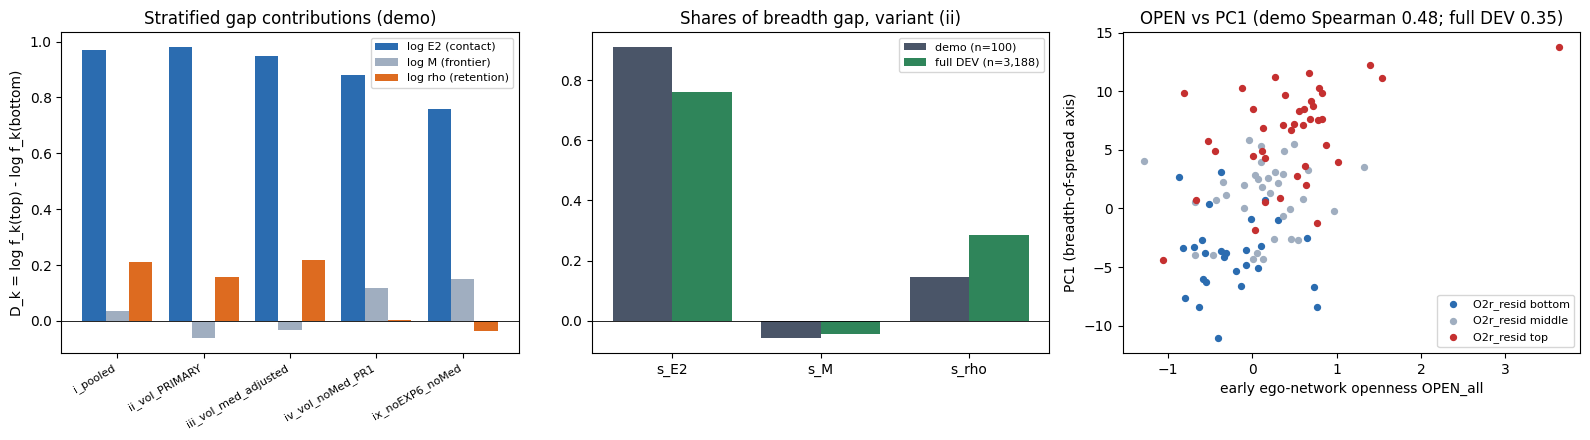

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
# (a) D_k per variant
names = list(res["variants"])
Dk = np.array([[res["variants"][n]["point"][k] for k in ("D_E2", "D_M", "D_rho")] for n in names])
x = np.arange(len(names)); w = 0.27
for j, (lab, col) in enumerate(zip(["log E2 (contact)", "log M (frontier)", "log rho (retention)"],
                                   ["#2b6cb0", "#a0aec0", "#dd6b20"])):
    ax[0].bar(x + (j - 1) * w, Dk[:, j], w, label=lab, color=col)
ax[0].axhline(0, color="k", lw=0.6); ax[0].set_xticks(x); ax[0].set_xticklabels(names, rotation=30, ha="right", fontsize=8)
ax[0].set_ylabel("D_k = log f_k(top) - log f_k(bottom)"); ax[0].set_title("Stratified gap contributions (demo)"); ax[0].legend(fontsize=8)
# (b) shares demo vs full (primary)
lab = ["s_E2", "s_M", "s_rho"]
demo_s = [pp[k] for k in lab]; full_s = [H["shares_DEV_primary"][k] for k in lab]
xx = np.arange(3)
ax[1].bar(xx - 0.2, demo_s, 0.4, label=f"demo (n={len(T)})", color="#4a5568")
ax[1].bar(xx + 0.2, full_s, 0.4, label="full DEV (n=3,188)", color="#2f855a")
ax[1].axhline(0, color="k", lw=0.6); ax[1].set_xticks(xx); ax[1].set_xticklabels(lab)
ax[1].set_title("Shares of breadth gap, variant (ii)"); ax[1].legend(fontsize=8)
# (c) OPEN vs continuum PC1
cols = {"top": "#c53030", "middle": "#a0aec0", "bottom": "#2b6cb0"}
for t_, g in T.groupby("tercile_full"):
    ax[2].scatter(g.OPEN_all, g.PC1, s=18, c=cols[t_], label=f"O2r_resid {t_}")
ax[2].set_xlabel("early ego-network openness OPEN_all"); ax[2].set_ylabel("PC1 (breadth-of-spread axis)")
rho = stats.spearmanr(T.OPEN_all, T.PC1)[0]
ax[2].set_title(f"OPEN vs PC1 (demo Spearman {rho:.2f}; full DEV {H['open_pc1_DEV']['all']['spearman']['rho']:.2f})")
ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()